# Lending Club Machine Learning Final Project

## Objective
We aim to answer two questions:

1. Will they pay back the loan in full? (Classification)
2. What will be our annualized return? (Regression)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import joblib

In [3]:
#Load Data
df = pd.read_csv("https://raw.githubusercontent.com/MattDBailey/ANOP330/refs/heads/main/Data/BucknellLendingClubHistoricalData.csv")

df.head()

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,fico_range_high,fico_range_low,revol_bal,revol_util,total_pymnt,last_pymnt_d,recoveries,loan_length,term_num,ret_PESS
0,44756846,10000,10000,36 months,9.9,322.63,B,10+ years,MORTGAGE,43717.0,...,794,790,59708,19.0,11485.6780,2017-06-01,0.0,26.021069,36,4.952260
1,99480680,34050,34050,60 months,28.6,1074.40,F,10+ years,MORTGAGE,85000.0,...,699,695,16779,76.0,41436.5400,2017-12-01,0.0,9.035093,60,4.338643
2,88321792,9600,9600,36 months,10.4,311.98,B,< 1 year,OWN,37000.0,...,684,680,10148,48.0,10528.5460,2017-09-01,0.0,13.010534,36,3.224118
3,58401079,5000,5000,36 months,9.9,161.32,B,3 years,MORTGAGE,120000.0,...,674,670,14607,38.0,5480.6100,2016-10-01,0.0,13.010534,36,3.204066
4,92749250,9000,9000,36 months,17.9,325.33,D,< 1 year,RENT,70000.0,...,664,660,5344,66.0,10473.4795,2017-11-01,0.0,11.992033,36,5.457331


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   50000 non-null  int64  
 1   loan_amnt            50000 non-null  int64  
 2   funded_amnt          50000 non-null  int64  
 3   term                 50000 non-null  object 
 4   int_rate             50000 non-null  float64
 5   installment          50000 non-null  float64
 6   grade                50000 non-null  object 
 7   emp_length           47092 non-null  object 
 8   home_ownership       50000 non-null  object 
 9   annual_inc           50000 non-null  float64
 10  verification_status  50000 non-null  object 
 11  issue_d              50000 non-null  object 
 12  loan_status          50000 non-null  object 
 13  purpose              50000 non-null  object 
 14  dti                  50000 non-null  float64
 15  delinq_2yrs          50000 non-null 

,id,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,fico_range_high,fico_range_low,revol_bal,revol_util,total_pymnt,recoveries,loan_length,term_num,ret_PESS
count,5.000000e+04,50000.00000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,5.599018e+07,14400.50900,14393.575500,13.101658,437.761465,7.632052e+04,18.343213,0.315540,11.636780,0.214320,700.169620,696.16950,16452.994040,51.579558,14840.282257,246.361633,21.007104,41.722560,1.170508
std,3.803097e+07,8704.84105,8702.226387,4.745160,261.766674,6.079697e+04,11.258257,0.870534,5.462231,0.591434,31.896222,31.89566,22299.572175,24.470251,10345.292353,1013.433492,12.441947,10.227211,8.154176
min,6.141900e+04,1000.00000,1000.000000,5.300000,14.770000,1.000000e+02,0.000000,0.000000,1.000000,0.000000,664.000000,660.00000,0.000000,0.000000,49.840000,0.000000,0.919937,36.000000,-33.054610
25%,2.005762e+07,8000.00000,8000.000000,9.600000,248.695000,4.600000e+04,11.870000,0.000000,8.000000,0.000000,674.000000,670.00000,6047.000000,33.000000,6883.689500,0.000000,10.973532,36.000000,1.117244
50%,5.721489e+07,12000.00000,12000.000000,12.700000,373.235000,6.500000e+04,17.730000,0.000000,11.000000,0.000000,694.000000,690.00000,11205.000000,52.000000,12096.215000,0.000000,19.975769,36.000000,3.541981
75%,8.394268e+07,20000.00000,20000.000000,15.900000,579.212500,9.000000e+04,24.080000,0.000000,14.000000,0.000000,714.000000,710.00000,19857.500000,70.000000,20658.266500,0.000000,32.033512,36.000000,5.761498
max,1.454988e+08,40000.00000,40000.000000,30.900000,1714.540000,6.100000e+06,999.000000,26.000000,68.000000,21.000000,850.000000,845.00000,959754.000000,152.000000,62663.617000,33457.460000,66.005460,60.000000,16.028273


In [5]:
#Data Cleansing

#Drop ID
df = df.drop(columns=['id'], errors='ignore')

#Drop leakage columns
df = df.drop(columns=['total_pymnt','recoveries','last_pymnt_d','loan_length'], errors='ignore')

#Drop redundant columns
df = df.drop(columns=['funded_amnt','term'], errors='ignore')

In [6]:
#Handle missing values

df.isna().sum()

,0
loan_amnt,0
int_rate,0
installment,0
grade,0
emp_length,2908
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0
loan_status,0


In [7]:
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [8]:
#Convert Cat Vars
df = pd.get_dummies(df, drop_first=True)

In [9]:
#Targets
y_class = df['loan_status_Fully Paid']  # after get dummies
y_reg = df['ret_PESS']

X = df.drop(columns=['loan_status_Fully Paid','ret_PESS'])

In [10]:
#EDA
#Distribution of target

y_class.value_counts()

,count
loan_status_Fully Paid,
True,39987
False,10013


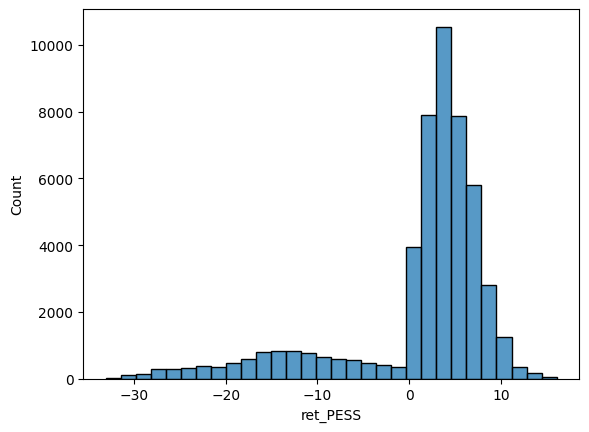

In [11]:
#Return distribution
sns.histplot(y_reg, bins=30)
plt.show()

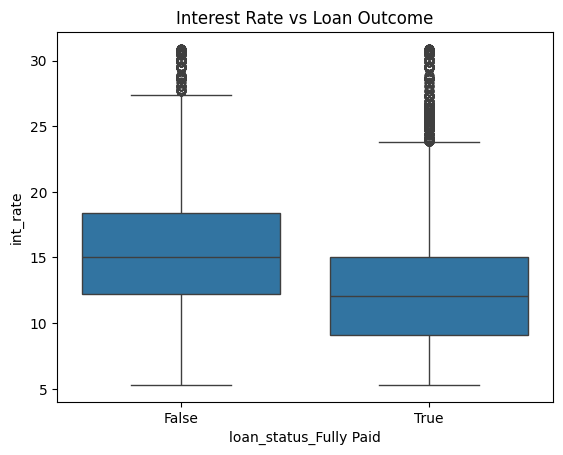

In [12]:
#Interest rate vs Loan Outcome
sns.boxplot(x='loan_status_Fully Paid', y='int_rate', data=df)
plt.title("Interest Rate vs Loan Outcome")
plt.show()

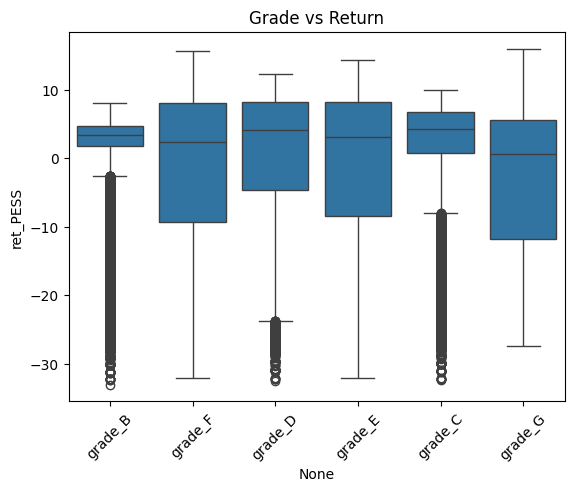

In [13]:
#Grade vs Return
sns.boxplot(x=df.filter(like='grade_').idxmax(axis=1), y=df['ret_PESS'])
plt.xticks(rotation=45)
plt.title("Grade vs Return")
plt.show()

In [14]:
# using only features 1-5 : int_rate, fico_range_high, loan_amnt, term_num, installment

features = ['int_rate', 'fico_range_high', 'loan_amnt', 'term_num', 'installment']

X = df[features]
y = df['ret_PESS']

# initial exploration with 5 features only

In [15]:
# split the data 80/20 into train-test (random = 42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# standardize (fit ONLY on training to prevent leakeage )
scaler = StandardScaler()
scaler.fit(X_train)

train_X_std = scaler.transform(X_train)
test_X_std = scaler.transform(X_test)

# Linear model
lin_model = LinearRegression()

# Cross-validation on TRAINING data
scores = cross_val_score(lin_model, train_X_std, y_train, cv=5, scoring='r2')

print("Linear Regression CV R^2:", scores)
print("Mean CV R^2:", scores.mean())

Linear Regression CV R^2: [0.0061666  0.01096088 0.01191893 0.00702912 0.00976529]
Mean CV R^2: 0.009168162741806252


In [17]:
# Lasso CV
lasso_model = LassoCV(cv=5, random_state=42)
lasso_model.fit(train_X_std, y_train)

print("Best alpha:", lasso_model.alpha_)

Best alpha: 0.0006565534036774423


### Interpret Models and Compare

In [18]:
# fit linear regression on the entire training data
lin_model.fit(train_X_std, y_train)

# Evaluate Linear Regression on test data
lin_reg_test_score = lin_model.score(test_X_std, y_test)
print(f"Linear Regression Test R^2: {lin_reg_test_score}")

# Evaluate LassoCV on test data
lasso_test_score = lasso_model.score(test_X_std, y_test)
print(f"LassoCV Test R^2: {lasso_test_score}")

Linear Regression Test R^2: 0.011918594734844912
LassoCV Test R^2: 0.011942821732456643


In [19]:
# display coefficients for Linear Regression
print("\nLinear Regression Coefficients:")
for feature, coef in zip(features, lin_model.coef_):
    print(f"{feature}: {coef}")

# display coefficients for LassoCV
print("\nLassoCV Coefficients:")
for feature, coef in zip(features, lasso_model.coef_):
    print(f"{feature}: {coef}")




Linear Regression Coefficients:
int_rate: -0.35298980673652963
fico_range_high: -0.10070483485071186
loan_amnt: 1.375619484390904
term_num: -0.8075243214199446
installment: -1.3429886354036147

LassoCV Coefficients:
int_rate: -0.3625335597219803
fico_range_high: -0.09933548596155205
loan_amnt: 1.290838991837134
term_num: -0.7820505461649903
installment: -1.2635411602066127


In [20]:
# rebuild full feature set (all non target cols)
features_all = [c for c in df.columns if c not in ['ret_PESS', 'loan_status_Fully Paid']]

X_all = df[features_all]
y_reg = df['ret_PESS']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_reg, test_size=0.2, random_state=42
)

scaler_all = StandardScaler()
X_train_std = scaler_all.fit_transform(X_train_all)
X_test_std  = scaler_all.transform(X_test_all)

# LassoCV (all features)****
lasso_full = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_full.fit(X_train_std, y_train_all)
lasso_r2 = lasso_full.score(X_test_std, y_test_all)
print(f"LassoCV Test R²: {lasso_r2:.4f}")

# decision tree regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_all, y_train_all)
dt_reg_r2 = dt_reg.score(X_test_all, y_test_all)
print(f"DT Regressor Test R²: {dt_reg_r2:.4f}")

# compare
print("\n Regression Model Comparison ")
print(f"LassoCV:      R² = {lasso_r2:.4f}")
print(f"DT Regressor: R² = {dt_reg_r2:.4f}")
print(f"Winner: {'LassoCV' if lasso_r2 > dt_reg_r2 else 'DT Regressor'}")

# both R squared's are pretty low overall, but LassoCV with all features is 6x better than the DT regressor.

LassoCV Test R²: 0.0672
DT Regressor Test R²: 0.0112

 Regression Model Comparison 
LassoCV:      R² = 0.0672
DT Regressor: R² = 0.0112
Winner: LassoCV


In [21]:

# setup classification targets
y_class = df['loan_status_Fully Paid']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_all, y_class, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_std = scaler_c.fit_transform(X_train_c)
X_test_c_std  = scaler_c.transform(X_test_c)

# decision tree classifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_c, y_train_c)
dt_auc = roc_auc_score(y_test_c, dt_clf.predict_proba(X_test_c)[:,1])
dt_acc = accuracy_score(y_test_c, dt_clf.predict(X_test_c))
print(f"DT Classifier  — Accuracy: {dt_acc:.4f} | AUC: {dt_auc:.4f}")

# logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_std, y_train_c)
log_auc = roc_auc_score(y_test_c, log_reg.predict_proba(X_test_c_std)[:,1])
log_acc = accuracy_score(y_test_c, log_reg.predict(X_test_c_std))
print(f"Logistic Reg   — Accuracy: {log_acc:.4f} | AUC: {log_auc:.4f}")

# compare
print("\n Classification Model Comparison ")
print(f"DT Classifier: Accuracy = {dt_acc:.4f} | AUC = {dt_auc:.4f}")
print(f"Logistic Reg:  Accuracy = {log_acc:.4f} | AUC = {log_auc:.4f}")
print(f"Winner (by AUC): {'DT Classifier' if dt_auc > log_auc else 'Logistic Regression'}")

DT Classifier  — Accuracy: 0.7927 | AUC: 0.6970
Logistic Reg   — Accuracy: 0.7927 | AUC: 0.7047

 Classification Model Comparison 
DT Classifier: Accuracy = 0.7927 | AUC = 0.6970
Logistic Reg:  Accuracy = 0.7927 | AUC = 0.7047
Winner (by AUC): Logistic Regression


In [22]:
# hyperparameter tuning on DT Classifier
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_c, y_train_c)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# evaluate tuned model on test set
dt_tuned = grid_search.best_estimator_
dt_tuned_auc = roc_auc_score(y_test_c, dt_tuned.predict_proba(X_test_c)[:,1])
print(f"Tuned DT Test AUC: {dt_tuned_auc:.4f}")
print(f"Original DT Test AUC: {dt_auc:.4f}")
print(f"Logistic Regression AUC: {log_auc:.4f}")
print(f"Winner: {'Tuned DT' if dt_tuned_auc > log_auc else 'Logistic Regression'}")

Best Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV AUC: 0.6902
Tuned DT Test AUC: 0.6972
Original DT Test AUC: 0.6970
Logistic Regression AUC: 0.7047
Winner: Logistic Regression


In [23]:
# Cross-validation on winning models
print("=== Cross-Validation on Final Models ===\n")

# LassoCV - regression winner
lasso_cv_scores = cross_val_score(lasso_full, X_train_std, y_train_all, cv=5, scoring='r2')
print(f"LassoCV CV R² scores: {lasso_cv_scores.round(4)}")
print(f"LassoCV Mean CV R²: {lasso_cv_scores.mean():.4f} (+/- {lasso_cv_scores.std():.4f})")

print()

# Logistic Regression - classification winner
log_cv_scores = cross_val_score(log_reg, X_train_c_std, y_train_c, cv=5, scoring='roc_auc')
print(f"Logistic Reg CV AUC scores: {log_cv_scores.round(4)}")
print(f"Logistic Reg Mean CV AUC: {log_cv_scores.mean():.4f} (+/- {log_cv_scores.std():.4f})")

=== Cross-Validation on Final Models ===

LassoCV CV R² scores: [0.067  0.062  0.0497 0.0645 0.0622]
LassoCV Mean CV R²: 0.0611 (+/- 0.0060)

Logistic Reg CV AUC scores: [0.6954 0.7004 0.7047 0.6985 0.6869]
Logistic Reg Mean CV AUC: 0.6972 (+/- 0.0060)


In [24]:
joblib.dump(lasso_full, 'lasso_model.pkl')
joblib.dump(scaler_all, 'scaler_reg.pkl')
joblib.dump(log_reg, 'log_model.pkl')
joblib.dump(scaler_c, 'scaler_clf.pkl')
joblib.dump(features_all, 'feature_names.pkl')

print("Done")

Done


### Interpretation and Comparison:

#### Regression Models (predicting ret_PESS):

LassoCV with all features achieved a test R squared of 0.067 and a mean cross-validation R squared of 0.061, with low variance across folds indicating a stable model.  The Decision Tree Regressor achieved a test R squared of 0.011, significantly underperforming LassoCV.  While both R squared values are low, this reflects the inherent noise in ret_PESS rather than a modeling failure; loan returns are difficult to predict from application-time data alone.  LassoCV is the clear winner for regression.

#### Classification Models (predicting loan default):

Logistic Regression achieved a test AUC of 0.705 and a mean CV AUC of 0.697, consistent across all five folds.  The Decision Tree Classifier, even after hyperparameter tuning via GridSearchCV, achieved a test AUC of 0.697, which is still below logistic regression.  Accuracy was identical at 79.3% for both, but AUC is the appropriate metric given the class imbalance (80% fully paid).  Logistic Regression is the winner for classification.